In [1]:
import numpy as np
import matplotlib as mpl
import glob
import os
import matplotlib.pyplot as plt
from scipy.io import savemat,loadmat,whosmat
import numpy.ma as ma
from matplotlib.gridspec import GridSpec
from scipy import stats
import xarray as xr
plt.rcParams.update({'font.size': 12})
import commondefs as myF

In [2]:
mydir = '../processed_netcdf/'
nm = 12
myhemi = ['SH','NH']
smallhemi=['sh','nh']
gencolours = ['blue','red','green','black']

In [3]:
obs_ds =  xr.open_dataset(mydir+'processed_OBS_sia_1979-2018.nc').sel(year=slice('1979','2014'))
obs_ds = myF.add_trend_stats_to_ds (obs_ds, obs_ds.sia_sh, 'sia_sh')

best_fit = np.zeros(obs_ds.sia_sh.shape)
for y, year in enumerate(obs_ds.year.values):
    best_fit[:,y,:] = year*obs_ds.sia_sh_slope + obs_ds.sia_sh_intercept

obs_ds['sia_sh_detrended'] = xr.DataArray(obs_ds.sia_sh - best_fit, dims = ['name','year','month'])
obsdata = [obs_ds.sia_sh.sel(month=9).mean(dim='year'),
           obs_ds.sia_sh.sel(month=2).mean(dim='year'),    
           obs_ds.sia_sh_detrended.sel(month=9).std(dim='year') ,
           obs_ds.sia_sh_detrended.sel(month=2).std(dim='year')]

# Compute IIAE

In [4]:
rootdir = '../processed_netcdf/'
subdirs = ['OBS_sic_1979-2014_clim','CMIP5_sic_1979-2014_clim','CMIP6_sic_1979-2014_clim']
cats = [f.split('_')[0] for f in subdirs]
print(cats)

['OBS', 'CMIP5', 'CMIP6']


degrees_east
12364.695


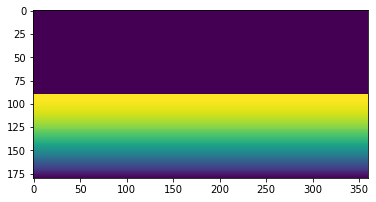

In [5]:
# get area for 1 degree grid
testfile = os.listdir(rootdir+subdirs[0]+'/remap/')[0]
ds = xr.open_dataset(rootdir+subdirs[0]+'/remap/'+testfile)
lon = ds.longitude
lat = ds.latitude
print(lon.units)
lat = np.swapaxes(np.tile(lat,(len(lon),1)),0,1)
lon = np.tile(lon,(len(lat),1))
        
to_rad = 2. *np.pi/360.
r_earth = 6371.22 # km
con = r_earth*to_rad
clat = np.cos(lat*to_rad)
dlon = lon[0,2] - lon[0,1]
dlat = lat[2,0] - lat[1,0]
dx = con*dlon*clat
dy = con*dlat
dxdy = -dy*dx
garea = dxdy

sh_area = np.where(lat<0.,garea,0.)
plt.imshow(sh_area)
print(np.max(sh_area))

In [6]:
chosennames = xr.open_dataset('../processed_netcdf/processed_CMIP5_sia_rcp45_r1.nc').name.values
chosennames = [f.strip().split('_')[0] for f in chosennames]

In [16]:
chosennames6 = xr.open_dataset('../processed_netcdf/processed_CMIP6_sia_historical_r1_updated.nc').name.values
chosennames6 = [f.strip().split('_')[0] for f in chosennames6]
print(chosennames6)
len(chosennames6)

tmpfiles = os.listdir('../processed_netcdf/CMIP6_sic_1979-2014_clim/remap/')
tmpfiles = [f.split('_')[2] for f in tmpfiles]
print(tmpfiles)
for model in chosennames6:
    if model not in tmpfiles:
        print(model)

['ACCESS-CM2', 'ACCESS-ESM1-5', 'AWI-CM-1-1-MR', 'BCC-CSM2-MR', 'BCC-ESM1', 'CAMS-CSM1-0', 'CESM2', 'CESM2-WACCM', 'CESM2-WACCM-FV2', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'CanESM5', 'E3SM-1-0', 'EC-Earth3', 'EC-Earth3-Veg', 'FGOALS-f3-L', 'FIO-ESM-2-0', 'GFDL-CM4', 'GFDL-ESM4', 'GISS-E2-1-G', 'GISS-E2-1-G-CC', 'GISS-E2-1-H', 'HadGEM3-GC31-LL', 'HadGEM3-GC31-MM', 'INM-CM4-8', 'INM-CM5-0', 'IPSL-CM6A-LR', 'MIROC-ES2L', 'MIROC6', 'MPI-ESM-1-2-HAM', 'MPI-ESM1-2-HR', 'MPI-ESM1-2-LR', 'MRI-ESM2-0', 'NESM3', 'NorCPM1', 'NorESM2-LM', 'NorESM2-MM', 'SAM0-UNICON', 'UKESM1-0-LL']
['SAM0-UNICON', 'EC-Earth3', 'GFDL-ESM4', 'BCC-ESM1', 'NorESM2-MM', 'CNRM-ESM2-1', 'INM-CM4-8', 'ACCESS-CM2', 'E3SM-1-0', 'NorCPM1', 'HadGEM3-GC31-LL', 'INM-CM5-0', 'EC-Earth3-Veg', 'MPI-ESM-1-2-HAM', 'NESM3', 'CanESM5', 'BCC-CSM2-MR', 'MIROC-ES2L', 'CESM2-WACCM-FV2', 'ACCESS-ESM1-5', 'MPI-ESM1-2-LR', 'FGOALS-f3-L', 'CESM2', 'NorESM2-LM', 'IPSL-CM6A-LR', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'CNRM-CM6-1', 'CNRM-CM6-1-H

In [17]:
obs_sic = []
iiae_gens = []
names = []
for c,cat in enumerate(cats):
    mynames = []
    myfiles = [f for f in sorted(os.listdir(rootdir+subdirs[c]+'/remap/')) if 'sic' in f or 'conc' in f]
   
    if c==1:
        myfiles = [f for f in myfiles if ('_r1i' in f and f.split('_')[2] in chosennames)]
    elif c==2:
        myfiles = [f for f in myfiles if (f.split('_')[2] in chosennames6)]
  
    iiae = np.zeros([len(myfiles),2])
    
    
    for f, file in enumerate(myfiles):
        print(c,f,file)
        ds = xr.open_dataset(rootdir+subdirs[c]+'/remap/'+file)
        if file.split('_')[2] not in mynames:
            mynames.append(file.split('_')[2])
            print(cat,file.split('_')[2])
            if 'month' in ds.coords:
                ds = ds.rename({'month':'time'})

            if 'CMIP5' not in cat:
                ds=ds.isel(time=[1,8])
            ds = myF.lat_renamer(ds)
            
            if 'siconca' in file:
                ds = ds.rename({'siconca':'siconc'})

            if 'CMIP5' in cat:
                ds = ds.rename({'sic':'siconc'})
            if 'osisaf' in file:
                ds = ds.rename({'sic':'siconc'})
                ds.siconc.values = 100.*ds.siconc.values
            if 'AWI' in file:
                ds = ds.rename({'seaice':'siconc'})
                ds.siconc.values = 100.*ds.siconc.values
            if 'HadGEM3-GC31-MM' in file:
                ds.siconc.values = 100.*ds.siconc.values
            
            print(ds.siconc.max())
            ds.siconc.values= ds.siconc.where(ds.siconc<=100.)
            ds.siconc.time.values = [1,8]
            ds.siconc.values = ds.siconc.values/100.

            sia = np.sum(np.tile(sh_area,(2,1,1))*ds.siconc,axis=(1,2))

            if c==0:
                obs_sic.append(ds.siconc)
                obs_sic_mean = obs_sic[0]
            else:           
                    sic = ds.siconc

                    overest = sic.values - obs_sic_mean
                    overest = np.where(overest>0.,overest,0.)
                    overest = np.sum(np.tile(sh_area,(2,1,1))*overest,axis=(1,2))

                    underest = obs_sic_mean - sic.values
                    underest = np.where(underest>0.,underest,0.)
                    underest = np.sum(np.tile(sh_area,(2,1,1))*underest,axis=(1,2))
                    iiae[f,:] = overest+underest

    iiae_gens.append(iiae/1000000.)
    names.append(mynames)

0 0 siconc_OBS_Bootstrap_monthly_sh_1979-2014.nc
OBS Bootstrap
<xarray.DataArray 'siconc' ()>
array(99.75999451)
0 1 siconc_OBS_NASA-Team_monthly_sh_1979-2014.nc
OBS NASA-Team
<xarray.DataArray 'siconc' ()>
array(98.11999512)
0 2 siconc_OBS_osisaf_monthly_sh_1979-2014.nc
OBS osisaf
<xarray.DataArray 'siconc' ()>
array(100.)
1 0 conc_1979-2014_ACCESS1-0_r1i1p1.nc
CMIP5 ACCESS1-0
<xarray.DataArray 'siconc' ()>
array(99.98174286)
1 1 conc_1979-2014_ACCESS1-3_r1i1p1.nc
CMIP5 ACCESS1-3
<xarray.DataArray 'siconc' ()>
array(99.99694824)
1 2 conc_1979-2014_BNU-ESM_r1i1p1.nc
CMIP5 BNU-ESM
<xarray.DataArray 'siconc' ()>
array(99.79275513)
1 3 conc_1979-2014_CCSM4_r1i1p1.nc
CMIP5 CCSM4
<xarray.DataArray 'siconc' ()>
array(99.99128723)
1 4 conc_1979-2014_CESM1-BGC_r1i1p1.nc
CMIP5 CESM1-BGC
<xarray.DataArray 'siconc' ()>
array(99.99628448)
1 5 conc_1979-2014_CESM1-CAM5_r1i1p1.nc
CMIP5 CESM1-CAM5
<xarray.DataArray 'siconc' ()>
array(99.9942627)
1 6 conc_1979-2014_CMCC-CMS_r1i1p1.nc
CMIP5 CMCC-CMS
<x

<xarray.DataArray 'siconc' ()>
array(99.99912262)
2 34 siconc_SImon_NorESM2-LM_historical_r1i1p1f1_gn_197901-201412.nc
CMIP6 NorESM2-LM
<xarray.DataArray 'siconc' ()>
array(99.99874878)
2 35 siconc_SImon_NorESM2-MM_historical_r1i1p1f1_gn_197901-201412.nc
CMIP6 NorESM2-MM
<xarray.DataArray 'siconc' ()>
array(99.99897766)
2 36 siconc_SImon_SAM0-UNICON_historical_r1i1p1f1_gn_197901-201412.nc
CMIP6 SAM0-UNICON
<xarray.DataArray 'siconc' ()>
array(99.99652863)
2 37 siconc_SImon_UKESM1-0-LL_historical_r1i1p1f2_gn_197901-201412.nc
CMIP6 UKESM1-0-LL
<xarray.DataArray 'siconc' ()>
array(99.99881744)
2 38 siconca_SImon_GISS-E2-1-G-CC_historical_r1i1p1f1_gn_197901-201412.nc
CMIP6 GISS-E2-1-G-CC
<xarray.DataArray 'siconc' ()>
array(99.99855804)
2 39 siconca_SImon_GISS-E2-1-G_historical_r1i1p1f1_gn_197901-201412.nc
CMIP6 GISS-E2-1-G
<xarray.DataArray 'siconc' ()>
array(99.99830627)


# Now for the figure

CMIP3 19
n models  38
1 1
4.798598500000001
n models  40
2 1
3.813831875
n models  38
1 0
1.763249125
n models  40
2 0
1.6151193125
CMIP5 38
n models  38
1 1
4.798598500000001
n models  40
2 1
3.813831875
n models  38
1 0
1.763249125
n models  40
2 0
1.6151193125


/Users/lettieroach/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:30: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
/Users/lettieroach/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:30: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
/Users/lettieroach/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:30: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes curren

CMIP6 40
Observations  [16.49923051 14.59919349 16.07280074] 15.723741577234543
CMIP6 Feb multi-model-median =  1.41668756468408
Observations  [2.28334699 2.00845589 2.17314554] 2.1549828043464356
Observations  [0.33732583 0.35004626 0.34725187] 0.3448746516358719
Observations  [0.27445659 0.25547643 0.25515552] 0.2616961804127867
n models  38
1 1
4.798598500000001
n models  40
2 1
3.813831875
n models  38
1 0
1.763249125
n models  40
2 0
1.6151193125


/Users/lettieroach/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:30: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
/Users/lettieroach/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:30: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
/Users/lettieroach/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:30: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes curren

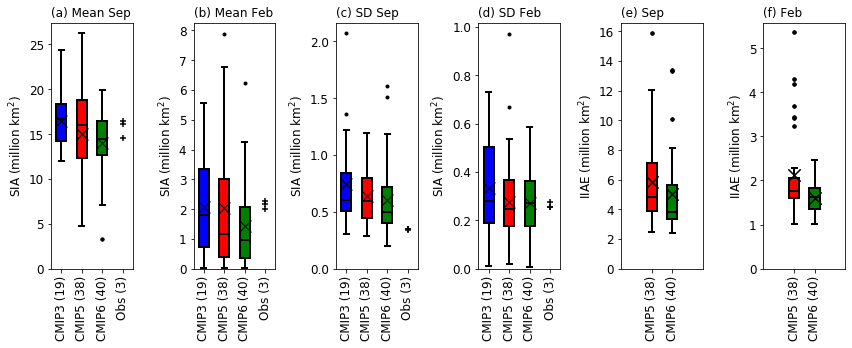

In [18]:
plt.rcParams.update({'font.size': 12})
exps = ['historical+SRES1AB','rcp45','historical']
nmodels = []
mymonths = [1,0] # for IIAE

plotnames = ['(a) Mean Sep','(b) Mean Feb','(c) SD Sep','(d) SD Feb']
ens = ['r1','r1','r1_updated']
maxs = [30,8,2,1.2]
fig = plt.figure(figsize=(12.,5))

for g,gen in enumerate(['CMIP3','CMIP5','CMIP6']):
    
    model_ds = xr.open_dataset(mydir+'processed_'+gen+'_sia_'+exps[g]+'_'+ens[g]+'.nc').sel(year=slice('1979','2014'))
    model_ds = myF.add_trend_stats_to_ds (model_ds, model_ds.sia_sh, 'sia_sh')
    
    best_fit = np.zeros(model_ds.sia_sh.shape)
    for y, year in enumerate(model_ds.year.values):
        best_fit[:,y,:] = year*model_ds.sia_sh_slope + model_ds.sia_sh_intercept

    model_ds['sia_sh_detrended'] = xr.DataArray(model_ds.sia_sh - best_fit, dims = ['name','year','month'])
    
    print(gen,len(model_ds.name.values))
    nmodels.append(len(model_ds.name.values))
    plotdata = [model_ds.sia_sh.sel(month=9).mean(dim='year'),
                model_ds.sia_sh.sel(month=2).mean(dim='year'),    
                model_ds.sia_sh_detrended.sel(month=9).std(dim='year') ,
                model_ds.sia_sh_detrended.sel(month=2).std(dim='year')]
    
    for p in range(len(plotnames)):
        ax = plt.subplot(1,6,p+1)
        
        if p==1:
            if gen=='CMIP6':
                print('CMIP6 Feb multi-model-median = ',np.mean(plotdata[p].values))
        
        bp = ax.boxplot(plotdata[p].values, positions=[g],widths=.5,patch_artist=True,showmeans=True,
                       whiskerprops = dict(linewidth=2),capprops = dict(linewidth=2))
        plt.setp(bp['fliers'],marker='.',markerfacecolor='black')
        plt.setp(bp['medians'],linewidth=2,c='black')
        plt.setp(bp['boxes'],facecolor = gencolours[g],linewidth=2)
        plt.setp(bp['means'],markerfacecolor='black',markeredgecolor='black',markersize=12,marker='x')
        
        if p==2:
            ax.set_yticks([0,.5,1.,1.5,2.])

        if g==2:
            for o in range(len(obsdata[p].values)):
                ax.scatter(3.,obsdata[p].values[o],marker='+',c='black')
            
            print('Observations ',obsdata[p].values,np.mean(obsdata[p].values))

            ax.set_title(plotnames[p],fontsize=12,loc='left')
            
            ax.set_ylabel('SIA (million km$^2$)')
            ax.set_xticks(np.arange(4))
            ax.set_xticklabels(['CMIP3 ('+str(nmodels[0])+')',
                                'CMIP5 ('+str(nmodels[1])+')',
                                'CMIP6 ('+str(nmodels[2])+')',
                                'Obs (3)'],rotation='vertical')
          
            ax.set_xlim([-.5,3.5])
            ax.set_ylim(bottom=0.)
            
    for p in range(2):    
        ax = plt.subplot(1,6,4+p+1)
        for i in [1,2]:
            print('n models ',len(names[i]))
            print(i,mymonths[p])
            bp = ax.boxplot(iiae_gens[i][:,mymonths[p]].flatten(),patch_artist=True,showmeans = True,widths=.5,
                            positions=[i+1],whiskerprops = dict(linewidth=2),capprops = dict(linewidth=2))
            plt.setp(bp['means'],markerfacecolor='black',markeredgecolor='black',markersize=12,marker='x',)

            for box in bp['boxes']:
                box.set( facecolor = gencolours[i],linewidth=2)#'#1b9e77' )
            for median in bp['medians']:
                median.set(linewidth=2,c='black')
            plt.setp(bp['fliers'],marker='.',markerfacecolor='black')
            print(np.median(iiae_gens[i][:,mymonths[p]]))        
        ax.set_title(['(e) Sep','(f) Feb'][p],fontsize=12,loc='left')
        ax.set_ylabel('IIAE (million km$^2$)',fontsize=12)
        ax.set_xticks([2,3])
        ax.set_xticklabels(['CMIP5 ('+str(len(names[1]))+')','CMIP6 ('+str(len(names[2]))+')'],rotation='vertical',fontsize=12)
        ax.set_xlim([0.5,4.5])
        ax.set_ylim(bottom=0.)

plt.tight_layout()
fig.savefig('fig2',bbox_inches='tight',dpi=600)
plt.show(); plt.close()
  

CMIP6 257
CMIP6 Feb multi-model-median =  2.0086717054923304
CMIP6 37
Observations  [16.49923051 14.59919349 16.07280074] 15.723741577234543
CMIP6 Feb multi-model-median =  1.4154758672396504
Observations  [2.28334699 2.00845589 2.17314554] 2.1549828043464356
Observations  [0.33732583 0.35004626 0.34725187] 0.3448746516358719
Observations  [0.27445659 0.25547643 0.25515552] 0.2616961804127867


/Users/lettieroach/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:28: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
/Users/lettieroach/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:28: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
/Users/lettieroach/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:28: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes curren

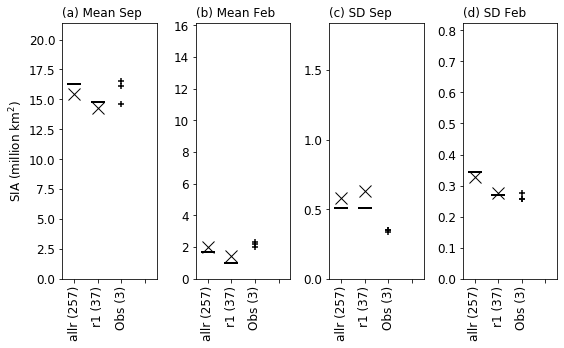

In [25]:
plt.rcParams.update({'font.size': 12})
nmodels = []

plotnames = ['(a) Mean Sep','(b) Mean Feb','(c) SD Sep','(d) SD Feb']
ens = ['allr','r1']
maxs = [30,8,2,1.2]
fig = plt.figure(figsize=(8.,5))

for g,en in enumerate(ens):
    
    model_ds = xr.open_dataset(mydir+'processed_CMIP6_sia_historical_'+ens[g]+'.nc').sel(year=slice('1979','2014'))
    model_ds = myF.add_trend_stats_to_ds (model_ds, model_ds.sia_sh, 'sia_sh')
    
    best_fit = np.zeros(model_ds.sia_sh.shape)
    for y, year in enumerate(model_ds.year.values):
        best_fit[:,y,:] = year*model_ds.sia_sh_slope + model_ds.sia_sh_intercept

    model_ds['sia_sh_detrended'] = xr.DataArray(model_ds.sia_sh - best_fit, dims = ['name','year','month'])
    
    print(gen,len(model_ds.name.values))
    nmodels.append(len(model_ds.name.values))
    plotdata = [model_ds.sia_sh.sel(month=9).mean(dim='year'),
                model_ds.sia_sh.sel(month=2).mean(dim='year'),    
                model_ds.sia_sh_detrended.sel(month=9).std(dim='year') ,
                model_ds.sia_sh_detrended.sel(month=2).std(dim='year')]
    
    for p in range(len(plotnames)):
        ax = plt.subplot(1,len(plotnames),p+1)
        
        if p==1:
            if gen=='CMIP6':
                print('CMIP6 Feb multi-model-median = ',np.mean(plotdata[p].values))
        
        bp = ax.boxplot(plotdata[p].values, positions=[g],widths=.5,patch_artist=True,showmeans=True,
                       whiskerprops = dict(linewidth=0),capprops = dict(linewidth=0))
        plt.setp(bp['fliers'],marker='')
        plt.setp(bp['medians'],linewidth=2,c='black')
        plt.setp(bp['boxes'],facecolor = 'white',linewidth=0)
        plt.setp(bp['means'],markerfacecolor='black',markeredgecolor='black',markersize=12,marker='x')
        
        if p==2:
            ax.set_yticks([0,.5,1.,1.5,2.])

        if g==1:
            for o in range(len(obsdata[p].values)):
                ax.scatter(2.,obsdata[p].values[o],marker='+',c='black')
            
            print('Observations ',obsdata[p].values,np.mean(obsdata[p].values))

            ax.set_title(plotnames[p],fontsize=12,loc='left')
            if p==0:
                ax.set_ylabel('SIA (million km$^2$)')
            ax.set_xticks(np.arange(4))
            ax.set_xticklabels(['allr ('+str(nmodels[0])+')',
                                'r1 ('+str(nmodels[1])+')',
                                'Obs (3)'],rotation='vertical')
          
            ax.set_xlim([-.5,3.5])
            ax.set_ylim(bottom=0.)

plt.tight_layout()
plt.show(); plt.close()
  